# "Sales and Profit Analysis for Amazon Orders"

## Project Description:
#### The objective of this project is to perform a comprehensive analysis of Amazon's sales data to uncover meaningful business insights. This includes identifying the most profitable product categories, understanding customer purchase behavior, evaluating sales performance across different geographic regions, and analyzing order patterns over time. The insights derived will help optimize business decisions, improve product strategies, and enhance overall sales and profitability.



### Key Questions:

1. Which product categories generate the highest sales and profit?

2. What are the top-selling products based on quantity?

3. Which cities generate the highest profit?

4. What is the monthly  trend of sales over the years?

5. What is the average profit margin per product category?

6. Which states have the highest number of orders and total sales?



In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create the data frame

df = pd.read_excel("Amazon 2_Raw.xlsx", sheet_name="Walmart")


In [3]:
df

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825
...,...,...,...,...,...,...,...,...,...,...
3198,CA-2013-125794,2013-09-30,2013-10-04,MarisLaWare@gmail.com,"United States,Los Angeles,California",Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,15.2208
3199,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,15.6332
3200,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Phones,Aastra 57i VoIP phone,258.576,2,19.3932
3201,CA-2014-121258,2014-02-27,2014-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,13.3200


### Data Cleaning

In [4]:
# view the first few rows

df.head()

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


In [5]:
#checking column names and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   object        
 1   Order Date    3203 non-null   datetime64[ns]
 2   Ship Date     3203 non-null   datetime64[ns]
 3   EmailID       3203 non-null   object        
 4   Geography     3203 non-null   object        
 5   Category      3203 non-null   object        
 6   Product Name  3203 non-null   object        
 7   Sales         3203 non-null   float64       
 8   Quantity      3203 non-null   int64         
 9   Profit        3203 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 250.4+ KB


#### Conclusion: There are no missing or null values in the dataset and Order Date and Ship Date are already in datetime format also the Columns are typed correctly for analysis.



In [6]:
#  Drop unnecessary column

df.drop(["EmailID"], axis=1,  inplace=True)

#### Conclusion: Removed EmailID since it’s not useful for insights or analysis.

In [7]:
df.head()

,Order ID,Order Date,Ship Date,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


In [8]:
# Check for duplicate rows

df.duplicated().sum()

0

#### Conclusion: No duplicate rows were found in the dataset, indicating that each entry is unique and does not need to be removed or handled.

In [9]:
# Split the Geography column into 3 new columns

df[['Country', 'City', 'State']] = df['Geography'].str.split(',', expand=True)

# Remove extra spaces (if any)
df['Country'] = df['Country'].str.strip()
df['City'] = df['City'].str.strip()
df['State'] = df['State'].str.strip()

# Drop the original Geography column
df.drop(['Geography'], axis=1,  inplace=True)


#### Conclusion: Split Geography into 3 clean columns — Country, City, and State — for easier filtering and visualization.

In [10]:
df.head()

,Order ID,Order Date,Ship Date,Category,Product Name,Sales,Quantity,Profit,Country,City,State
0,CA-2013-138688,2013-06-13,2013-06-17,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,United States,Los Angeles,California
1,CA-2011-115812,2011-06-09,2011-06-14,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,United States,Los Angeles,California
2,CA-2011-115812,2011-06-09,2011-06-14,Art,Newell 322,7.280,4,1.9656,United States,Los Angeles,California
3,CA-2011-115812,2011-06-09,2011-06-14,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,United States,Los Angeles,California
4,CA-2011-115812,2011-06-09,2011-06-14,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,United States,Los Angeles,California


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   object        
 1   Order Date    3203 non-null   datetime64[ns]
 2   Ship Date     3203 non-null   datetime64[ns]
 3   Category      3203 non-null   object        
 4   Product Name  3203 non-null   object        
 5   Sales         3203 non-null   float64       
 6   Quantity      3203 non-null   int64         
 7   Profit        3203 non-null   float64       
 8   Country       3203 non-null   object        
 9   City          3203 non-null   object        
 10  State         3203 non-null   object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(6)
memory usage: 275.4+ KB


In [12]:
# Create profit_margin column

df['profit_margin'] = df['Profit'] / df['Sales']
df.head()


,Order ID,Order Date,Ship Date,Category,Product Name,Sales,Quantity,Profit,Country,City,State,profit_margin
0,CA-2013-138688,2013-06-13,2013-06-17,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,United States,Los Angeles,California,0.4700
1,CA-2011-115812,2011-06-09,2011-06-14,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,United States,Los Angeles,California,0.2900
2,CA-2011-115812,2011-06-09,2011-06-14,Art,Newell 322,7.280,4,1.9656,United States,Los Angeles,California,0.2700
3,CA-2011-115812,2011-06-09,2011-06-14,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,United States,Los Angeles,California,0.1000
4,CA-2011-115812,2011-06-09,2011-06-14,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,United States,Los Angeles,California,0.3125


#### Conclusion: Added new column profit_margin to analyze efficiency of sales across products/categories.

In [13]:
# Create time-related columns

df['order_month'] = df['Order Date'].dt.to_period('M')
df['order_year'] = df['Order Date'].dt.year
df.head()

,Order ID,Order Date,Ship Date,Category,Product Name,Sales,Quantity,Profit,Country,City,State,profit_margin,order_month,order_year
0,CA-2013-138688,2013-06-13,2013-06-17,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,United States,Los Angeles,California,0.4700,2013-06,2013
1,CA-2011-115812,2011-06-09,2011-06-14,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,United States,Los Angeles,California,0.2900,2011-06,2011
2,CA-2011-115812,2011-06-09,2011-06-14,Art,Newell 322,7.280,4,1.9656,United States,Los Angeles,California,0.2700,2011-06,2011
3,CA-2011-115812,2011-06-09,2011-06-14,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,United States,Los Angeles,California,0.1000,2011-06,2011
4,CA-2011-115812,2011-06-09,2011-06-14,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,United States,Los Angeles,California,0.3125,2011-06,2011


#### Conclusion: New columns order_month and order_year created for trend-based visualizations.



## Final Dataset Check

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   object        
 1   Order Date     3203 non-null   datetime64[ns]
 2   Ship Date      3203 non-null   datetime64[ns]
 3   Category       3203 non-null   object        
 4   Product Name   3203 non-null   object        
 5   Sales          3203 non-null   float64       
 6   Quantity       3203 non-null   int64         
 7   Profit         3203 non-null   float64       
 8   Country        3203 non-null   object        
 9   City           3203 non-null   object        
 10  State          3203 non-null   object        
 11  profit_margin  3203 non-null   float64       
 12  order_month    3203 non-null   period[M]     
 13  order_year     3203 non-null   int32         
dtypes: datetime64[ns](2), float64(3), int32(1), int64(1), object(6), period[

In [15]:
df.describe()

,Order Date,Ship Date,Sales,Quantity,Profit,profit_margin,order_year
count,3203,3203,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440192,2013-05-14 01:25:25.195129600,226.493233,3.828910,33.849032,0.219487,2012.729941
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.990000,1.000000,-3399.980000,-2.100000,2011.000000
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.440000,2.000000,3.852000,0.100000,2012.000000
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.840000,3.000000,11.166400,0.290000,2013.000000
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.809000,5.000000,33.000400,0.375000,2014.000000
max,2014-12-31 00:00:00,2015-01-06 00:00:00,13999.960000,14.000000,6719.980800,0.500000,2014.000000
std,NaN,NaN,524.876877,2.260947,174.109081,0.279832,1.138640


In [16]:
df.head()

,Order ID,Order Date,Ship Date,Category,Product Name,Sales,Quantity,Profit,Country,City,State,profit_margin,order_month,order_year
0,CA-2013-138688,2013-06-13,2013-06-17,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,United States,Los Angeles,California,0.4700,2013-06,2013
1,CA-2011-115812,2011-06-09,2011-06-14,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,United States,Los Angeles,California,0.2900,2011-06,2011
2,CA-2011-115812,2011-06-09,2011-06-14,Art,Newell 322,7.280,4,1.9656,United States,Los Angeles,California,0.2700,2011-06,2011
3,CA-2011-115812,2011-06-09,2011-06-14,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,United States,Los Angeles,California,0.1000,2011-06,2011
4,CA-2011-115812,2011-06-09,2011-06-14,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,United States,Los Angeles,California,0.3125,2011-06,2011


## Data Visualization

### Which product categories generate the highest sales and profit?

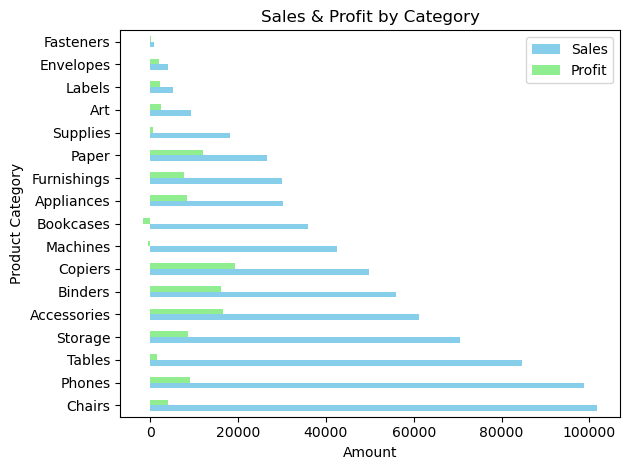

In [17]:
# Grouping sales and profit by category
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

# Visualizing the result using horizontal bar plot
category_summary.plot(kind='barh', color=['skyblue', 'lightgreen'])
plt.title('Sales & Profit by Category')
plt.xlabel('Amount')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()




#### Conclusion:
#### Chairs generate the highest sales, meaning they bring in the most revenue.
#### Copiers generate the highest profit, indicating they are the most profitable despite possibly lower sales.



## What are the top-selling products based on quantity?

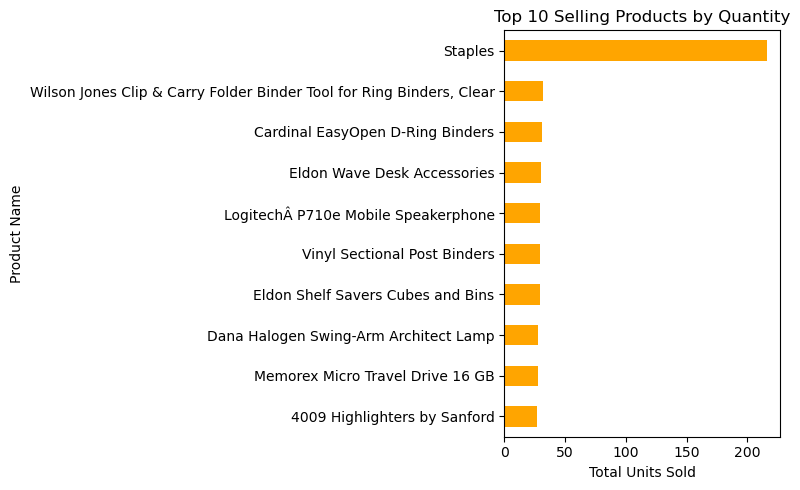

In [18]:
# Grouping by Product Name and summing the Quantity sold
top_products = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10)

# Visualizing the result with a horizontal bar chart
top_products.plot(kind='barh', figsize=(8, 5), color='orange')
plt.title('Top 10 Selling Products by Quantity')  
plt.xlabel('Total Units Sold')                    
plt.ylabel('Product Name')                        
plt.gca().invert_yaxis()                          # Flips chart to show highest on top
plt.tight_layout()                                
plt.show()                                       


#### Conclusion: "Staples are the top-selling product by a significant margin, followed by various binders and office accessories, indicating high demand for basic office supplies."

##  Which cities generate the highest profit?

City
Los Angeles        30440.7579
Seattle            29156.0967
San Francisco      17507.3854
San Diego           6377.1960
North Las Vegas     2247.6899
Sacramento          2069.6859
Great Falls         1582.7071
Des Moines          1250.3434
Anaheim             1234.0036
Brentwood           1216.8104
Name: Profit, dtype: float64


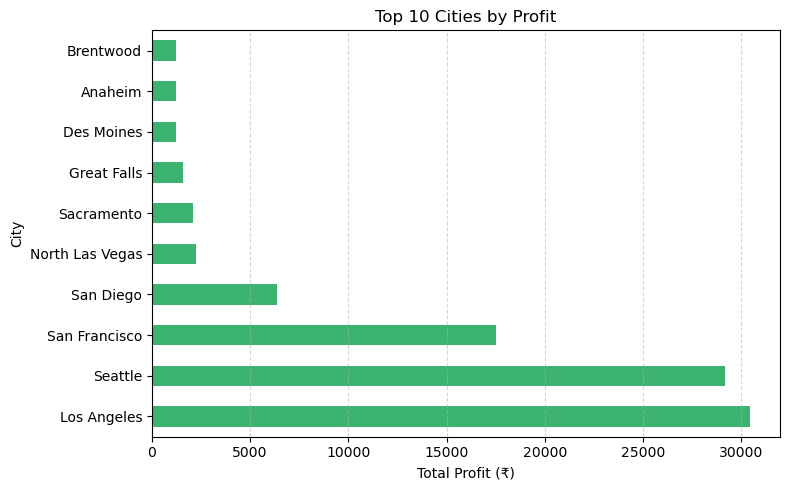

In [19]:
# Step 1: Group by City and sum Profit
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(10)

# Step 2: Display the top 10 cities with highest profit
print(city_profit)

# Step 3: Visualize the result
city_profit.plot(kind='barh', figsize=(8,5), color='mediumseagreen')
plt.title('Top 10 Cities by Profit')
plt.xlabel('Total Profit (₹)')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### Conclusion: "Los Angeles is the most profitable city in the dataset, contributing the highest total profit among all cities.

## What is the monthly trend of sales over the years?

In [30]:
# Group the data by year and month, and calculate the total sales for each month
monthly_sales_trend = df.groupby(['order_year', 'order_month'])['Sales'].sum().reset_index()

# If you want to see the result:
print(monthly_sales_trend)


    order_year order_month       Sales
0         2011     2011-01   2648.0570
1         2011     2011-02   1348.6220
2         2011     2011-03  11008.8980
3         2011     2011-04   9343.4870
4         2011     2011-05   6570.4380
5         2011     2011-06   9629.4220
6         2011     2011-07  21808.5530
7         2011     2011-08  13248.2310
8         2011     2011-09  14900.5370
9         2011     2011-10   8728.7580
10        2011     2011-11  23191.6245
11        2011     2011-12  25456.4055
12        2012     2012-01   6026.7360
13        2012     2012-02   2004.9140
14        2012     2012-03  15461.4120
15        2012     2012-04   9056.0240
16        2012     2012-05  12042.6555
17        2012     2012-06   5088.9500
18        2012     2012-07   7089.8260
19        2012     2012-08  12548.3590
20        2012     2012-09  13898.9240
21        2012     2012-10  14016.6800
22        2012     2012-11  14548.8960
23        2012     2012-12  28182.8730
24        2013     2013-0

#### Conclusion: The data shows a consistent upward trend in sales over the years, with 2014 outperforming previous years. Sales are generally higher towards the end of the year, especially in November and December, likely due to seasonal spikes from holiday shopping. However, months like January and February tend to show lower sales, indicating a post-holiday slump. 

## What is the average profit margin per product category?

In [31]:
# Calculate the average profit margin per product category
avg_profit_margin = df.groupby('Category')['profit_margin'].mean()

# Display the result
print(avg_profit_margin)


Category
Accessories    0.241386
Appliances     0.264669
Art            0.282900
Binders        0.166587
Bookcases     -0.257752
Chairs         0.021498
Copiers        0.332500
Envelopes      0.453022
Fasteners      0.308819
Furnishings    0.301053
Labels         0.462694
Machines      -0.065812
Paper          0.453922
Phones         0.085740
Storage        0.132321
Supplies       0.163007
Tables        -0.053966
Name: profit_margin, dtype: float64


#### Conclusion: Categories like Envelopes, Labels, and Paper have the highest profit margins, while Bookcases, Machines, and Tables show negative margins. Most categories fall in the moderate range, indicating opportunities for cost optimization and pricing adjustments.

## Which states have the highest number of orders and total sales?

            total_orders  total_sales
State                                
Arizona              224   35282.0010
California          2001  457687.6315
Colorado             182   32108.1180
Idaho                 21    4382.4860
Montana               15    5589.3520
Nevada                39   16729.1020
New Mexico            37    4783.5220
Oregon               124   17431.1500
Utah                  53   11220.0560
Washington           506  138641.2700
Wyoming                1    1603.1360


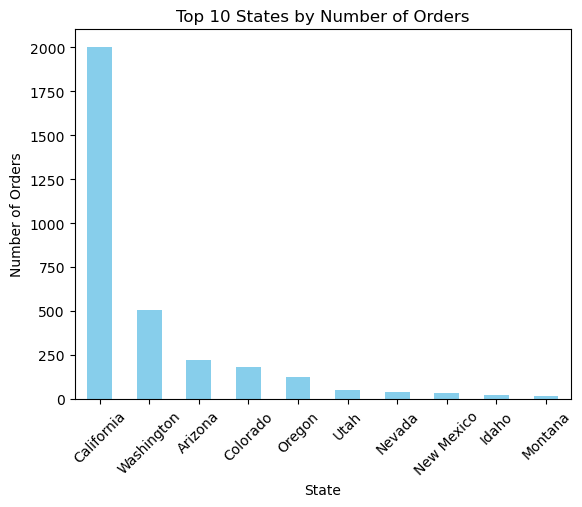

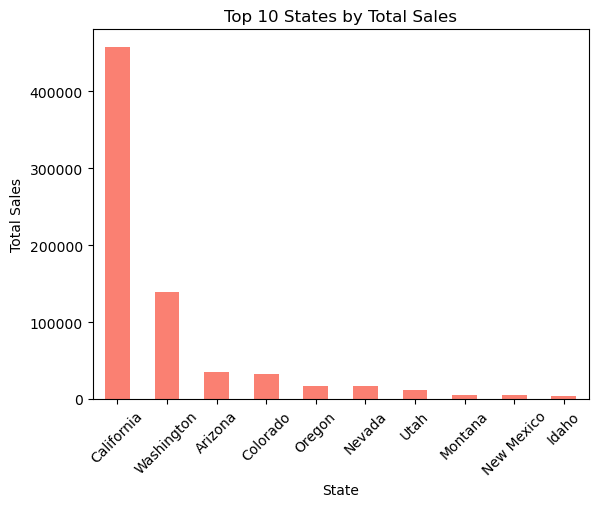

In [37]:
# Group by state and calculate the number of orders and total sales
state_summary = df.groupby('State').agg(
    total_orders=('Order ID', 'count'),
    total_sales=('Sales', 'sum')
)
print(state_summary)

# Plot the states with the highest number of orders
state_summary['total_orders'].sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 States by Number of Orders')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

# Plot the states with the highest total sales
state_summary['total_sales'].sort_values(ascending=False).head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 States by Total Sales')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


#### Conclusion: California leads both in the highest number of orders and total sales by a significant margin. States like Arizona and Washington also show strong sales, while other states have much lower order volumes and total sales.








